In [67]:
import numpy
print(numpy.__version__)

2.5.1


## Projeto: "Convergência Estatística Aplicada à Precificação de Opções via Modelo Binomial"
Demonstrar empiricamente, através de simulação, como a LFGN, a LGGN e o TLC (via Teorema de De Moivre-Laplace) sustentam o método de precificação de opções por árvore binomial — e quantificar a incerteza da estimativa via Monte Carlo.

In [68]:
import numpy as np
import matplotlib.pyplot as mt
from scipy.stats import binom , norm
import yfinance as yf
import pandas as pd
import requests as rt
import math as M 

Obtenção dos dados que seram usados

In [69]:
dados = yf.download(
    "PETR4.SA",
    period="2y"
)



[*********************100%***********************]  1 of 1 completed


## Modulo  0: preparação e coleta dos dados

Calcular o Log-retorno diario

In [70]:
close  = dados['Close'].squeeze()
razao = close / close.shift(1) # razao entre o fechamento de hoje com o  dia anterior


log = np.log(razao) # calcula o log-retorno diario
log_retorno = log.dropna() 

dp = log_retorno.std() # desvio padrao
dp_anual = dp * np.sqrt(252) # volatilidade anual





print(dp_anual)



0.24539760865045004


Puxando API do banco central

In [71]:
codigo = 11
n = 1
url = f'https://api.bcb.gov.br/dados/serie/bcdata.sgs.{codigo}/dados/ultimos/{n}?formato=json'
resposta = rt.get(url)
selic = resposta.json()
r = float(selic[0]['valor']) # Taxa livre de risco



Extraindo os restante dos dados

In [72]:
s0 = close.iat[-1] # Preço Atual da ação
strike = round(s0) # Preço em exercicio, arredondado
T = 0.25 # tempo de vencimento do mercado
n_steps = 200 # Divide em quantos remos vai ter ate a data de vencimento


OUTPUTS

In [73]:

def outputs(vol):
    deltaT = T/n_steps
    u = M.exp(vol * M.sqrt(deltaT))
    d = 1/u
    p = (M.exp(r * deltaT) - d) / (u - d)

    return u,d, p

u, d, p = outputs(dp_anual)

print(u, d, p)


1.0087138622352252 0.9913614132198838 0.5016152289703896


Função  simuladora de trajetoria

In [74]:
# Achando o valor de k 

def simulacao(s, P, sub, des, si, K_strike):
    k = np.random.binomial(s, P)
    Sn = si * (sub ** k) * (des ** (s - k))
    payoff = max(Sn - K_strike, 0)

    return Sn, k, payoff

Sn, k, payoff = simulacao(n_steps, p, u, d, s0, strike)

print(Sn, k, payoff)


49.683563184949485 109 7.6835631849494845


## Calculando o preço teorico


In [75]:
esperanca = 0

for k in range(201):
    probk = binom.pmf(k, n_steps, p)  # probabilidade de k altas

    Snk = s0 * (u ** k) * (d ** (n_steps - k))

    payoffk = max(Snk - strike, 0)

    contribuicao = probk * payoffk

    esperanca += contribuicao


def teorico(j, t, e):
    C = np.exp(-j * t) * e
    return C


C = teorico(r, T, esperanca)

print(C)




2.6215603560106375


## Modulo 2: Lei Fraca dos Grandes Numeros

# Simulação 

In [76]:

simulacao_N = [10, 100, 1000, 10000]
m_repeticao = 1000

resultados = {}

def estimador_preço(N):
    payoff_N = []

    for m in range(N):
        _, _, pyf= simulacao(n_steps, p, u, d, s0, strike)
        payoff_N.append(float(pyf))

    media_payoff = np.mean(payoff_N)

    Cn = M.exp(-r * T) * media_payoff

    return Cn


for k in simulacao_N:
    Cn_lista = []
    for i in range(m_repeticao):
        cn = estimador_preço(k)
        Cn_lista.append(float(cn))


    resultados[k] = Cn_lista


e = 0.20

margem_erro = {}
for s in simulacao_N:
    v = np.abs(np.array(resultados[s]) - C)
    qtd = np.sum(v > e)

    margem_erro[s] = float(qtd) / 1000
        



print(resultados)
print(margem_erro)






{10: [3.8737821585102323, 2.0116116719102703, 2.661771569553703, 3.234643517246574, 3.2811403482386514, 1.950693739759271, 3.0781842986494192, 1.6995973652308025, 1.5274359056469395, 2.01037094865509, 1.3007985725456375, 4.005339829075018, 2.720590751898512, 2.774562011853239, 1.4060220668880805, 3.36418708246446, 2.9979347046606035, 2.0257645017648773, 4.451635621307948, 2.4036690066528803, 1.5356305496078386, 3.8955809299672044, 1.8740673237128436, 3.9180166550254425, 1.9132153526714095, 3.95740958881143, 0.9778269535095889, 2.1881753196733142, 2.1409773558450373, 2.2811689400822015, 2.8575887796563753, 4.342541347120379, 2.9635122713754907, 1.8326347997623444, 2.4994885992557734, 3.1819724967231093, 2.619287421729725, 1.514752119711331, 1.6847075790474155, 3.254759133623583, 1.6931785434156439, 1.8121713125858971, 4.92791572372919, 3.9998129868543084, 4.834066491494833, 2.308808842145614, 3.3155365950432265, 1.841763447193653, 1.6213219058433461, 4.746981997616203, 4.730938452850221

# Grafico

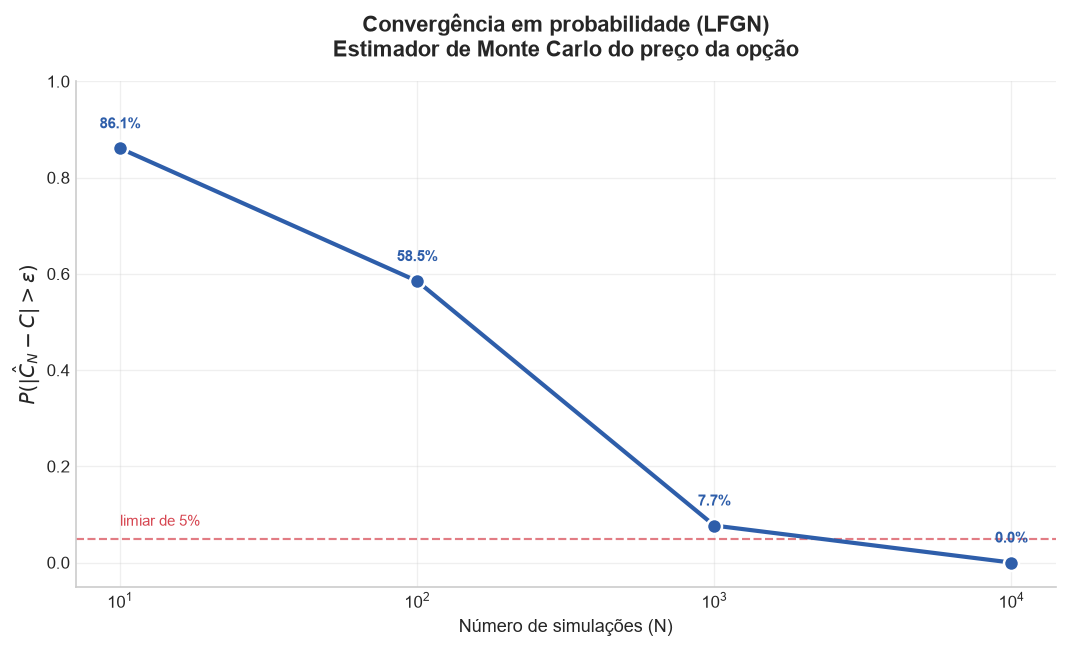

In [77]:
import matplotlib.pyplot as plt

# Estilo geral mais limpo
plt.style.use('seaborn-v0_8-whitegrid')

x = list(margem_erro.keys())
y = list(margem_erro.values())

fig, ax = plt.subplots(figsize=(9, 5.5), dpi=120)

# Linha principal com marcadores maiores e cor customizada
ax.plot(
    x, y,
    marker='o',
    markersize=9,
    linewidth=2.5,
    color='#2E5EAA',
    markerfacecolor='#2E5EAA',
    markeredgecolor='white',
    markeredgewidth=1.5,
    zorder=3
)

# Linha de referência (ex: 5% de erro aceitável)
ax.axhline(y=0.05, color='#D64550', linestyle='--', linewidth=1.3, alpha=0.7, zorder=1)
ax.text(x[0], 0.07, 'limiar de 5%', color='#D64550', fontsize=9, va='bottom')

# Anotações com os valores exatos em cada ponto
for xi, yi in zip(x, y):
    ax.annotate(
        f'{yi*100:.1f}%',
        xy=(xi, yi),
        xytext=(0, 12),
        textcoords='offset points',
        ha='center',
        fontsize=9,
        fontweight='bold',
        color='#2E5EAA'
    )

ax.set_xscale('log')
ax.set_xlabel('Número de simulações (N)', fontsize=11)
ax.set_ylabel(r'$P(|\hat{C}_N - C| > \varepsilon)$', fontsize=12)
ax.set_title('Convergência em probabilidade (LFGN)\nEstimador de Monte Carlo do preço da opção', fontsize=13, fontweight='bold', pad=15)

# Remove bordas superior e direita
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_ylim(-0.05, 1.0)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Modulo 2: Lei Forte dos Grandes Numeros

In [ ]:
payoff_soma = []
c = 100000
for z in range(c):
    _, _, pyf = simulacao(n_steps, p, u, d, s0, strike)
    payoff_soma.append(float(pyf))
print(payoff_soma)

soma = np.cumsum(payoff_soma) # Soma acumulada
deno = np.arange(1, c + 1) 

X = soma / deno

Xn = X * M.exp(-r * T)
print(Xn)
=




[9.43807311843662, 0.0, 5.16336678577111, 0.0, 4.352036686937694, 9.43807311843662, 3.5546635333805483, 0.0, 0.0, 5.988898127447833, 6.828879285635452, 0.0, 0.0, 0.0, 0.0, 4.352036686937694, 5.988898127447833, 0.0, 1.2439053742840471, 2.0008318122359725, 1.2439053742840471, 3.5546635333805483, 0.0, 0.0, 3.5546635333805483, 9.43807311843662, 0.0, 0.0, 1.2439053742840471, 3.5546635333805483, 0.0, 0.0, 0.0, 7.6835631849494845, 0.5000000000000924, 1.2439053742840471, 0.5000000000000924, 1.2439053742840471, 0.0, 4.352036686937694, 1.2439053742840471, 2.7710072300733017, 9.43807311843662, 0.0, 9.43807311843662, 9.43807311843662, 2.7710072300733017, 0.0, 0.5000000000000924, 8.553207177110906, 0.0, 3.5546635333805483, 0.5000000000000924, 0.0, 3.5546635333805483, 1.2439053742840471, 0.0, 0.5000000000000924, 0.0, 4.352036686937694, 5.988898127447833, 0.0, 2.7710072300733017, 3.5546635333805483, 3.5546635333805483, 5.16336678577111, 0.0, 2.7710072300733017, 0.0, 0.5000000000000924, 3.554663533380

Grafico

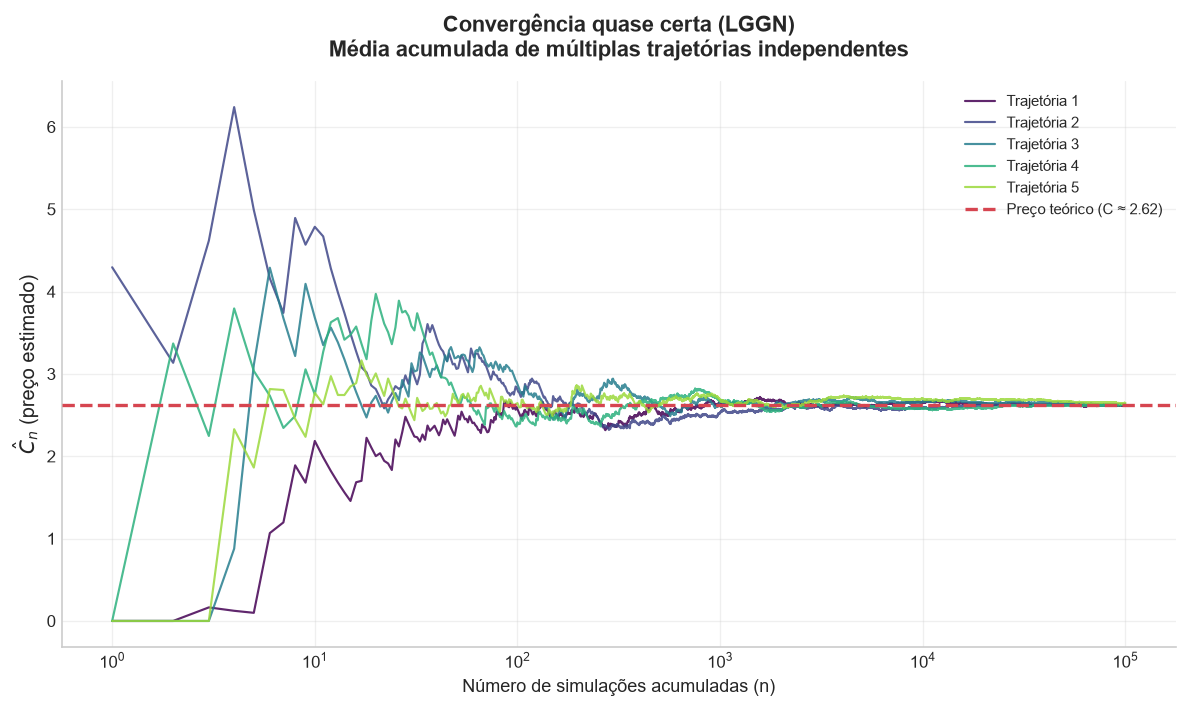

In [79]:
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(figsize=(10, 6), dpi=120)

# Gera e plota 5 trajetórias diferentes, cada uma com sua própria aleatoriedade
n_trajetorias = 5
cores = plt.cm.viridis(np.linspace(0, 0.85, n_trajetorias))

for idx in range(n_trajetorias):
    payoff_soma = []
    for z in range(c):
        _, _, pyf = simulacao(n_steps, p, u, d, s0, strike)
        payoff_soma.append(float(pyf))

    soma = np.cumsum(payoff_soma)
    deno = np.arange(1, c + 1)
    X = soma / deno
    Xn_traj = X * M.exp(-r * T)

    ax.plot(deno, Xn_traj, linewidth=1.3, alpha=0.85, color=cores[idx], label=f'Trajetória {idx+1}')

# Linha de referência: preço teórico
ax.axhline(y=C, color='#D64550', linestyle='--', linewidth=2, label=f'Preço teórico (C ≈ {C:.2f})', zorder=5)

ax.set_xscale('log')
ax.set_xlabel('Número de simulações acumuladas (n)', fontsize=11)
ax.set_ylabel(r'$\hat{C}_n$ (preço estimado)', fontsize=12)
ax.set_title('Convergência quase certa (LGGN)\nMédia acumulada de múltiplas trajetórias independentes', fontsize=13, fontweight='bold', pad=15)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Modulo 3